# Team 08 - Yeseswini: shared env + baselines + Agent A (DQN) - v2 (all steps)
Runtime: CPU. **New session? Run Step 1 first, then jump to where you left off.**
Steps 3-8 are already done if their outputs exist in `MyDrive/team08/agentA/`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 - Mount, unpack, install (run every new session)

In [2]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/RL_Project/files_coding/uav_inspection'
# --- where each member's outputs live (shared by all notebooks) ---
ROOT  = '/content/drive/MyDrive/RL_Project/files_coding'
A_DIR = f'{ROOT}/uav_inspection'      # Agent A (DQN)  - Yeseswini
B_DIR = f'{ROOT}/For_Leekhith'        # Agent B (PPO)  - Leekhith
C_DIR = f'{ROOT}/For_Mukhesh'         # Agent C (A2C) + detector cache - Mukhesh
CACHE = f'{C_DIR}/detector_cache.npz' # real-image detector cache

!mkdir -p $DRIVE/results
!rm -rf /content/uav_inspection
!unzip -o -q $DRIVE/uav_inspection.zip -d /content/
%cd /content/uav_inspection
!pip install -q gymnasium stable-baselines3 tensorboard
!ls scripts

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/uav_inspection
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 9.1 MB/s eta 0:00:00
build_detector_cache.py  run_baselines.py  train_agent_a.py
_path.py		 run_full_mode.py  train_agent_b.py
__pycache__		 test_env.py	   train_agent_c.py


## Step 3 - Smoke test

In [ ]:
!python scripts/test_env.py

[OK] analytic navigate  return= -22.75 coverage=0.79 steps=141
[OK] analytic refine    return=  -2.14 coverage=0.08 steps=30
[OK] analytic supervise return=  19.87 coverage=0.47 steps=7
[OK] learned  navigate  return= -25.77 coverage=0.79 steps=141
[OK] learned  refine    return=  -2.23 coverage=0.08 steps=30
[OK] learned  supervise return=   9.88 coverage=0.47 steps=7

ASCII render (U=UAV, .=unseen, digit=uncertainty*10):
553U6...........
23352...........
757.............
................
................
................
................
................
alt=mid battery=0.97

ALL TESTS PASSED


## Step 4 - Baselines (analytic)

In [ ]:
!python scripts/run_baselines.py --out $DRIVE/results


=== navigate (analytic) ===
random             return= -29.56±8.62  success=0.00  steps= 148.7  cov=0.51  unc=0.662  found=10.2/26  mIoU=0.244  energy=1.002
raster_mid         return=   6.20±0.07  success=0.00  steps= 199.0  cov=1.00  unc=0.351  found=20.9/26  mIoU=0.500  energy=1.000
raster_low         return=  35.43±0.09  success=1.00  steps= 123.0  cov=0.95  unc=0.219  found=23.5/26  mIoU=0.626  energy=0.625

=== refine (analytic) ===
random             return=  -2.24±0.17  success=0.00  steps=  30.0  cov=0.08  unc=0.963  found=1.1/26  mIoU=0.024  energy=0.240
fixed_orbit        return=  -2.29±0.08  success=0.00  steps=  30.0  cov=0.08  unc=0.963  found=1.1/26  mIoU=0.024  energy=0.240
scripted_approach  return=   5.68±0.16  success=1.00  steps=   3.5  cov=0.08  unc=0.961  found=1.2/26  mIoU=0.028  energy=0.028

=== supervise (analytic) ===
random             return=   4.07±9.13  success=1.00  steps=   3.0  cov=0.16  unc=0.903  found=3.0/26  mIoU=0.072  energy=0.066
rule_supervisor

## Step 5 - Train Agent A (~10 min)

In [ ]:
!python scripts/train_agent_a.py --steps 200000 --out $DRIVE/agentA

2026-09-27 06:05:45.802094: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-27 06:05:45.842926: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to /content/drive/MyDrive/RL_Project/files_coding/uav_inspection/agentA/tb/DQN_1
----------------------------------
|

## Step 7 - Learning curves

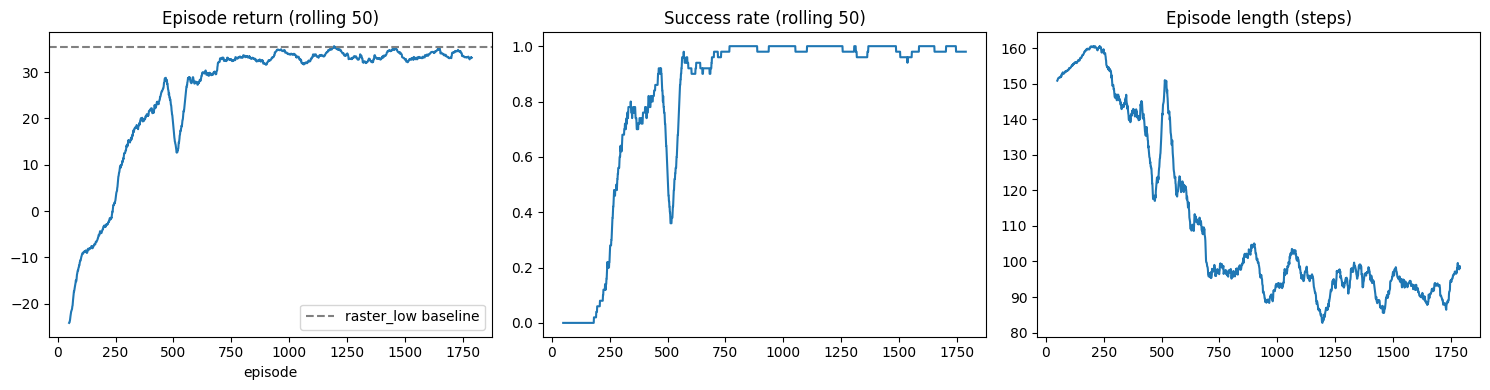

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
df = pd.read_csv(f'{DRIVE}/agentA/monitor_train.monitor.csv', skiprows=1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(df['r'].rolling(50).mean()); ax[0].set_title('Episode return (rolling 50)'); ax[0].set_xlabel('episode')
ax[0].axhline(35.43, ls='--', c='gray', label='raster_low baseline'); ax[0].legend()
ax[1].plot(df['success'].astype(float).rolling(50).mean()); ax[1].set_title('Success rate (rolling 50)')
ax[2].plot(df['l'].rolling(50).mean()); ax[2].set_title('Episode length (steps)')
plt.tight_layout(); plt.savefig(f'{DRIVE}/agentA/learning_curves.png', dpi=150); plt.show()

## Step 8 - Results table

In [ ]:
cols = ['policy','return_mean','success_mean','steps_mean','coverage_mean','mean_uncertainty_mean','defects_found_mean','miou_mean','energy_used_mean','train_minutes']
pd.read_csv(f'{DRIVE}/agentA/agentA_vs_baselines.csv')[cols].round(3)

,policy,return_mean,success_mean,steps_mean,coverage_mean,mean_uncertainty_mean,defects_found_mean,miou_mean,energy_used_mean,train_minutes
0,DQN (Agent A),35.060,1.0,88.3,0.999,0.319,21.80,0.539,0.502,5.7
1,raster_mid,6.202,0.0,199.0,1.000,0.351,20.95,0.500,1.000,5.7
2,raster_low,35.427,1.0,123.0,0.953,0.219,23.50,0.626,0.625,5.7


## Step 10 - Exploration sensitivity: epsilon decay (CO5, ~25 min)

In [ ]:
for frac in [0.1, 0.3, 0.6]:
    !python scripts/train_agent_a.py --steps 150000 --eps_fraction {frac} --out $DRIVE/agentA_eps{frac}

2026-09-27 06:14:39.373997: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-27 06:14:39.474957: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to /content/drive/MyDrive/RL_Project/files_coding/uav_inspection/agentA_eps0.1/tb/DQN_1
-----------------------------

## Step 10b - Compare the 3 schedules

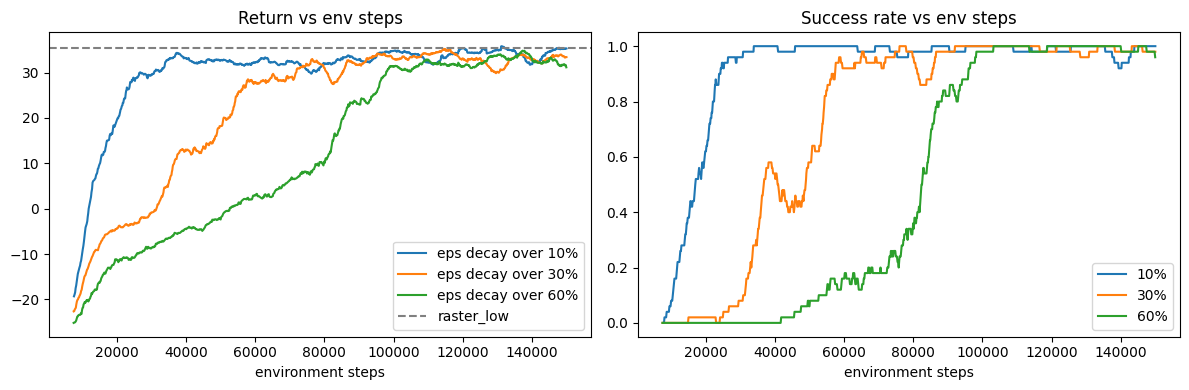

,eps_fraction,return,success,steps,energy,mIoU
0,0.1,37.78,1.0,74.70,0.397,0.559
1,0.3,34.47,1.0,92.70,0.520,0.552
2,0.6,28.09,0.8,120.65,0.637,0.539


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4)); rows = []
for frac in [0.1, 0.3, 0.6]:
    run = f'{DRIVE}/agentA_eps{frac}'
    d = pd.read_csv(f'{run}/monitor_train.monitor.csv', skiprows=1); steps = d['l'].cumsum()
    ax[0].plot(steps, d['r'].rolling(50).mean(), label=f'eps decay over {int(frac*100)}%')
    ax[1].plot(steps, d['success'].astype(float).rolling(50).mean(), label=f'{int(frac*100)}%')
    r = pd.read_csv(f'{run}/agentA_vs_baselines.csv').iloc[0]
    rows.append({'eps_fraction': frac, 'return': round(r.return_mean, 2), 'success': r.success_mean,
                 'steps': r.steps_mean, 'energy': round(r.energy_used_mean, 3), 'mIoU': round(r.miou_mean, 3)})
ax[0].axhline(35.43, ls='--', c='gray', label='raster_low'); ax[0].set_title('Return vs env steps'); ax[0].legend()
ax[1].set_title('Success rate vs env steps'); ax[1].legend()
for a in ax: a.set_xlabel('environment steps')
plt.tight_layout(); plt.savefig(f'{DRIVE}/agentA/eps_sensitivity.png', dpi=150); plt.show()
pd.DataFrame(rows)

## Step 11 - Live demo: state -> Q-values -> action -> reward -> next state (CO3)

In [ ]:
import torch
from stable_baselines3 import DQN
from env import InspectionEnv
ACTIONS = ['North', 'South', 'East', 'West', 'Climb', 'Descend']
model = DQN.load(f'{DRIVE}/agentA/best/best_model.zip', device='cpu')
env = InspectionEnv('navigate'); obs, info = env.reset(seed=1000)
for t in range(3):
    print(f'===== t={t} | STATE =====\n{env.render()}')
    print(f"coverage={info['coverage']:.2f}  mean_uncertainty={info['mean_uncertainty']:.3f}")
    with torch.no_grad():
        q = model.q_net(model.policy.obs_to_tensor(obs)[0])[0].numpy()
    print('Q-values:', {a: round(float(v), 2) for a, v in zip(ACTIONS, q)})
    action = int(q.argmax())
    obs, reward, term, trunc, info = env.step(action)
    print(f'ACTION -> {ACTIONS[action]}   REWARD = {reward:+.3f}\n')
print(f'===== NEXT STATE =====\n{env.render()}')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


===== t=0 | STATE =====
U54.............
544.............
775.............
................
................
................
................
................
alt=high battery=1.00
coverage=0.07  mean_uncertainty=0.971
Q-values: {'North': 15.87, 'South': 17.0, 'East': 16.85, 'West': 15.95, 'Climb': 16.14, 'Descend': 16.83}
ACTION -> South   REWARD = +0.239

===== t=1 | STATE =====
754.............
U44.............
775.............
457.............
................
................
................
................
alt=high battery=0.99
coverage=0.09  mean_uncertainty=0.961
Q-values: {'North': 16.59, 'South': 16.7, 'East': 16.79, 'West': 15.76, 'Climb': 16.07, 'Descend': 16.81}
ACTION -> Descend   REWARD = +0.228

===== t=2 | STATE =====
534.............
U24.............
555.............
457.............
................
................
................
................
alt=mid battery=0.98
coverage=0.09  mean_uncertainty=0.952
Q-values: {'North': 16.41, 'South': 16.5, 'East': 16.64, 

## Step 12 - Convergence, sample efficiency, regret (CO4)

Episodes trained: 1790 (199,957 env steps)
Convergence (success >= 95%): episode 563 = 82,064 env steps
Sample efficiency (95% of raster_low return): episode 938 = 120,311 env steps
Final 100-episode return: 33.75 +/- 3.74
Cumulative regret vs raster_low: 19047 (last 200 episodes add 402)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


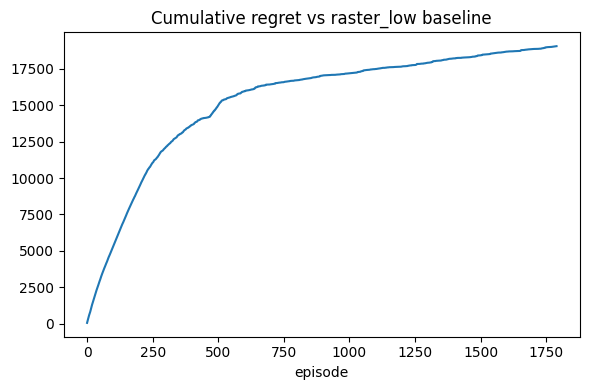

In [ ]:
df = pd.read_csv(f'{DRIVE}/agentA/monitor_train.monitor.csv', skiprows=1)
succ = df['success'].astype(float).rolling(50).mean(); ret = df['r'].rolling(50).mean(); cum = df['l'].cumsum(); REF = 35.43
conv = int(np.argmax(succ.values >= 0.95)) if (succ >= 0.95).any() else None
match = int(np.argmax(ret.values >= REF * 0.95)) if (ret >= REF * 0.95).any() else None
regret = np.maximum(0, REF - df['r']).cumsum()
print(f'Episodes trained: {len(df)} ({int(cum.iloc[-1]):,} env steps)')
if conv is not None: print(f'Convergence (success >= 95%): episode {conv} = {int(cum.iloc[conv]):,} env steps')
if match is not None: print(f'Sample efficiency (95% of raster_low return): episode {match} = {int(cum.iloc[match]):,} env steps')
print(f"Final 100-episode return: {df['r'].tail(100).mean():.2f} +/- {df['r'].tail(100).std():.2f}")
print(f'Cumulative regret vs raster_low: {regret.iloc[-1]:.0f} (last 200 episodes add {regret.iloc[-1]-regret.iloc[-201]:.0f})')
plt.figure(figsize=(6, 4)); plt.plot(regret); plt.title('Cumulative regret vs raster_low baseline')
plt.xlabel('episode'); plt.tight_layout(); plt.savefig(f'{DRIVE}/agentA/regret.png', dpi=150); plt.show()

## Step 13 - Flight path: DQN vs raster (poster figure)

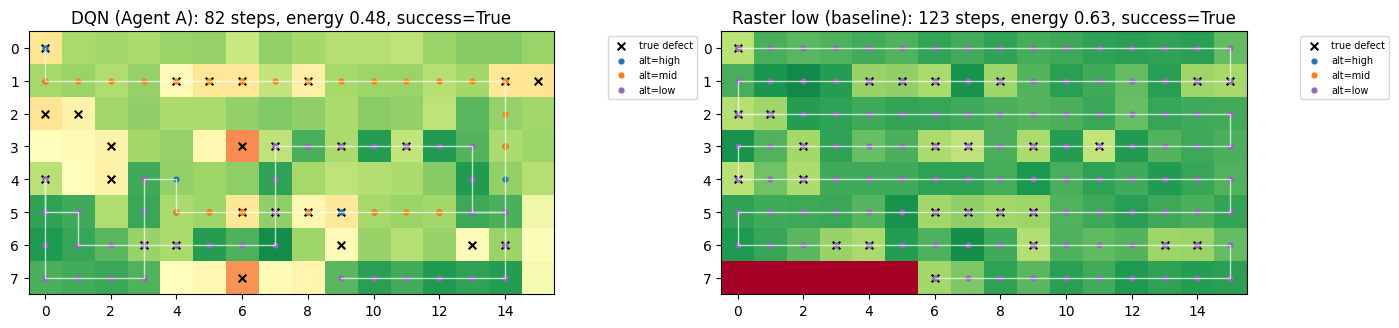

In [ ]:
from env.baselines import RasterNav
def rollout(policy, seed=1000):
    env = InspectionEnv('navigate'); obs, info = env.reset(seed=seed)
    if hasattr(policy, 'reset'): policy.reset()
    path, done = [(env.pos[0], env.pos[1], env.alt)], False
    while not done:
        obs, r, term, trunc, info = env.step(policy(obs)); done = term or trunc
        path.append((env.pos[0], env.pos[1], env.alt))
    return env, path, info
runs = {'DQN (Agent A)': lambda o: model.predict(o, deterministic=True)[0], 'Raster low (baseline)': RasterNav(2)}
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, (name, pol) in zip(ax, runs.items()):
    env, path, info = rollout(pol)
    a.imshow(env.cell_u().reshape(8, 16), cmap='RdYlGn_r', vmin=0, vmax=1)
    ys, xs = np.where(env.defect.reshape(8, 16)); a.scatter(xs, ys, marker='x', c='black', s=30, label='true defect')
    p = np.array(path); a.plot(p[:, 1], p[:, 0], c='white', lw=1, alpha=0.7)
    for alt, (lab, col) in enumerate(zip(['high', 'mid', 'low'], ['tab:blue', 'tab:orange', 'tab:purple'])):
        m = p[:, 2] == alt; a.scatter(p[m, 1], p[m, 0], c=col, s=12, label=f'alt={lab}')
    a.set_title(f"{name}: {info['steps']} steps, energy {info['energy_used']:.2f}, success={info['success']}")
    a.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.28, 1))
plt.tight_layout(); plt.savefig(f'{DRIVE}/agentA/trajectories.png', dpi=150); plt.show()

## Step 9 - REAL images (only after Mukhesh puts `detector_cache.npz` in `MyDrive/team08/`)
Honest expectation: this task is harder (weaker, noisier uncertainty signal). If DQN does not beat raster_low, report it as CO4 sample-efficiency evidence; keep analytic results as the main result.

In [3]:
CACHE = '/content/drive/MyDrive/RL_Project/files_coding/For_Mukhesh/detector_cache.npz'  # Mukhesh's cache
!python scripts/run_baselines.py --detector learned --cache $CACHE --out $DRIVE/results
!python scripts/train_agent_a.py --detector learned --cache $CACHE --steps 500000 --out $DRIVE/agentA_learned


=== navigate (learned) ===
random             return= -29.89±8.50  success=0.00  steps= 148.7  cov=0.51  unc=0.638  found=9.9/26  mIoU=0.243  energy=1.002
raster_mid         return=   8.80±7.58  success=0.05  steps= 191.4  cov=1.00  unc=0.302  found=21.2/26  mIoU=0.494  energy=0.962
raster_low         return=  33.77±0.41  success=1.00  steps= 123.1  cov=0.95  unc=0.264  found=24.2/26  mIoU=0.668  energy=0.626

=== refine (learned) ===
random             return=  -1.90±1.63  success=0.05  steps=  28.9  cov=0.08  unc=0.949  found=0.7/26  mIoU=0.015  energy=0.232
fixed_orbit        return=  -2.30±0.06  success=0.00  steps=  30.0  cov=0.08  unc=0.949  found=0.7/26  mIoU=0.015  energy=0.240
scripted_approach  return=   5.33±0.10  success=1.00  steps=   3.3  cov=0.08  unc=0.949  found=0.7/26  mIoU=0.015  energy=0.026

=== supervise (learned) ===
random             return=   4.27±9.48  success=1.00  steps=   3.0  cov=0.16  unc=0.892  found=2.7/26  mIoU=0.061  energy=0.059
rule_supervisor    

In [8]:
import pandas as pd

# Load one dataframe first to obtain the column structure
a_full = pd.read_csv(
    "/content/drive/MyDrive/RL_Project/files_coding/uav_inspection/agentA/agentA_vs_baselines.csv"
)

# Define 'cols' from the dataframe columns
cols = a_full.columns

# Process both datasets (excluding the last column 'train_minutes')
a = a_full[cols[:-1]]
a.insert(0, "detector", "analytic")

l = pd.read_csv(
    "/content/drive/MyDrive/RL_Project/files_coding/uav_inspection/agentA_learned/agentA_vs_baselines.csv"
)[cols[:-1]]
l.insert(0, "detector", "real (DeepCrack)")

# Concatenate into final rounded table
df_combined = pd.concat([a, l], ignore_index=True).round(3)

df_combined

,detector,policy,return_mean,steps_mean,success_mean,coverage_mean,mean_uncertainty_mean,defects_found_mean,defects_total_mean,false_positives_mean,...,return_std,steps_std,success_std,coverage_std,mean_uncertainty_std,defects_found_std,defects_total_std,false_positives_std,miou_std,energy_used_std
0,analytic,DQN (Agent A),35.060,88.30,1.00,0.999,0.319,21.80,26.0,2.10,...,4.013,22.729,0.000,0.002,0.001,1.249,0.0,1.338,0.017,0.138
1,analytic,raster_mid,6.202,199.00,0.00,1.000,0.351,20.95,26.0,1.95,...,0.072,0.000,0.000,0.000,0.002,1.532,0.0,1.161,0.011,0.000
2,analytic,raster_low,35.427,123.00,1.00,0.953,0.219,23.50,26.0,1.10,...,0.088,0.000,0.000,0.000,0.003,1.432,0.0,0.831,0.027,0.000
3,real (DeepCrack),DQN (Agent A),15.272,151.60,0.25,0.992,0.294,21.60,26.0,3.20,...,9.647,30.746,0.433,0.008,0.012,1.828,0.0,2.015,0.065,0.190
4,real (DeepCrack),raster_mid,8.805,191.45,0.05,1.000,0.302,21.20,26.0,2.15,...,7.585,32.910,0.218,0.000,0.012,1.860,0.0,1.388,0.065,0.165
5,real (DeepCrack),raster_low,33.771,123.10,1.00,0.954,0.264,24.20,26.0,7.25,...,0.410,0.300,0.000,0.002,0.012,1.288,0.0,2.681,0.046,0.002
